# 단일모델 baseline 성능 확인

이 노트북은 `위험도`를 하나의 MLP 회귀 모델로 직접 예측하는 baseline 결과를 확인한다.

- 학습을 자동으로 실행하지 않는다.
- 기존 산출물이 있으면 metrics/predictions를 읽어 핵심 지표를 계산한다.
- 산출물이 없으면 실행해야 할 명령을 출력한다.
- 비교용 지표는 `PR-AUC`, `F1`, `Precision@Top10%`, `Recall@Top10%`, `MAE`, `RMSE`를 사용한다.

In [1]:
from pathlib import Path
import os

def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'streamlit_app.py').exists() and (candidate / 'scripts').exists():
            return candidate
    raise FileNotFoundError('프로젝트 루트를 찾을 수 없습니다.')

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
os.chdir(PROJECT_ROOT)
print(f'PROJECT_ROOT = {PROJECT_ROOT}')

PROJECT_ROOT = /home/huichan/SPARV/SilverWalk


In [2]:
import json
import math
import shlex
import subprocess

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import average_precision_score, f1_score, mean_absolute_error, mean_squared_error

pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

In [3]:
REPORTS_DIR = PROJECT_ROOT / 'artifacts' / 'reports'
PREDICTIONS_DIR = PROJECT_ROOT / 'artifacts' / 'predictions'
MODELS_DIR = PROJECT_ROOT / 'artifacts' / 'models'

preferred_metrics_path = REPORTS_DIR / 'mlp_single_baseline_notebook_metrics.json'
preferred_predictions_path = PREDICTIONS_DIR / 'mlp_single_baseline_notebook_test_predictions.csv'
preferred_history_path = REPORTS_DIR / 'mlp_single_baseline_notebook_history.csv'
preferred_model_path = MODELS_DIR / 'mlp_single_baseline_notebook.keras'

metrics_candidates = [
    preferred_metrics_path,
    REPORTS_DIR / 'mlp_risk_metrics.json',
    REPORTS_DIR / 'mlp_risk_notebook_smoke_metrics.json',
    REPORTS_DIR / 'mlp_risk_smoke_metrics.json',
]
predictions_candidates = [
    preferred_predictions_path,
    PREDICTIONS_DIR / 'mlp_risk_test_predictions.csv',
    PREDICTIONS_DIR / 'mlp_risk_notebook_smoke_test_predictions.csv',
    PREDICTIONS_DIR / 'mlp_risk_smoke_test_predictions.csv',
]
history_candidates = [
    preferred_history_path,
    REPORTS_DIR / 'mlp_risk_history.csv',
    REPORTS_DIR / 'mlp_risk_notebook_smoke_history.csv',
    REPORTS_DIR / 'mlp_risk_smoke_history.csv',
]

def first_existing(paths):
    return next((path for path in paths if path.exists()), None)

metrics_path = first_existing(metrics_candidates)
predictions_path = first_existing(predictions_candidates)
history_path = first_existing(history_candidates)

file_status = pd.DataFrame([
    {'구분': 'preferred metrics', '경로': preferred_metrics_path.relative_to(PROJECT_ROOT), '존재': preferred_metrics_path.exists()},
    {'구분': 'preferred predictions', '경로': preferred_predictions_path.relative_to(PROJECT_ROOT), '존재': preferred_predictions_path.exists()},
    {'구분': 'preferred history', '경로': preferred_history_path.relative_to(PROJECT_ROOT), '존재': preferred_history_path.exists()},
    {'구분': 'selected metrics', '경로': metrics_path.relative_to(PROJECT_ROOT) if metrics_path else None, '존재': metrics_path is not None},
    {'구분': 'selected predictions', '경로': predictions_path.relative_to(PROJECT_ROOT) if predictions_path else None, '존재': predictions_path is not None},
    {'구분': 'selected history', '경로': history_path.relative_to(PROJECT_ROOT) if history_path else None, '존재': history_path is not None},
])
display(file_status)

,구분,경로,존재
0,preferred metrics,artifacts/reports/mlp_single_baseline_notebook...,False
1,preferred predictions,artifacts/predictions/mlp_single_baseline_note...,False
2,preferred history,artifacts/reports/mlp_single_baseline_notebook...,False
3,selected metrics,artifacts/reports/mlp_risk_notebook_smoke_metr...,True
4,selected predictions,artifacts/predictions/mlp_risk_notebook_smoke_...,True
5,selected history,artifacts/reports/mlp_risk_notebook_smoke_hist...,True


## 선택 실행: 단일모델 baseline 학습

아래 셀은 기본적으로 학습을 실행하지 않는다. 산출물이 없거나 새로 학습하려면 `RUN_TRAINING = True`로 바꾼 뒤 실행한다.

In [4]:
RUN_TRAINING = True

train_command = [
    'python', 'scripts/train/train_mlp.py',
    '--epochs', '100',
    '--batch-size', '1024',
    '--device', 'auto',
    '--verbose', '2',
    '--model-path', str(preferred_model_path),
    '--metrics-path', str(preferred_metrics_path),
    '--history-path', str(preferred_history_path),
    '--predictions-path', str(preferred_predictions_path),
]

print('실행 명령:')
print(shlex.join(train_command))

if RUN_TRAINING:
    subprocess.run(train_command, cwd=PROJECT_ROOT, check=True)
else:
    print('RUN_TRAINING=False 이므로 학습을 실행하지 않았습니다.')

실행 명령:
python scripts/train/train_mlp.py --epochs 100 --batch-size 1024 --device auto --verbose 2 --model-path /home/huichan/SPARV/SilverWalk/artifacts/models/mlp_single_baseline_notebook.keras --metrics-path /home/huichan/SPARV/SilverWalk/artifacts/reports/mlp_single_baseline_notebook_metrics.json --history-path /home/huichan/SPARV/SilverWalk/artifacts/reports/mlp_single_baseline_notebook_history.csv --predictions-path /home/huichan/SPARV/SilverWalk/artifacts/predictions/mlp_single_baseline_notebook_test_predictions.csv


I0000 00:00:1780776032.544415  355514 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780776033.262412  355514 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780776034.827289  355514 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
W0000 00:00:1780776036.507220  355514 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please mak

Epoch 1/100
309/309 - 2s - 6ms/step - loss: 0.1194 - mae: 0.3133 - rmse: 0.5510 - val_loss: 0.0909 - val_mae: 0.2181 - val_rmse: 0.4901 - learning_rate: 0.0010
Epoch 2/100
309/309 - 1s - 4ms/step - loss: 0.0915 - mae: 0.2401 - rmse: 0.4872 - val_loss: 0.0885 - val_mae: 0.2237 - val_rmse: 0.4801 - learning_rate: 0.0010
Epoch 3/100
309/309 - 1s - 4ms/step - loss: 0.0896 - mae: 0.2338 - rmse: 0.4810 - val_loss: 0.0874 - val_mae: 0.2229 - val_rmse: 0.4756 - learning_rate: 0.0010
Epoch 4/100
309/309 - 1s - 4ms/step - loss: 0.0883 - mae: 0.2308 - rmse: 0.4763 - val_loss: 0.0864 - val_mae: 0.2209 - val_rmse: 0.4731 - learning_rate: 0.0010
Epoch 5/100
309/309 - 1s - 4ms/step - loss: 0.0870 - mae: 0.2283 - rmse: 0.4717 - val_loss: 0.0847 - val_mae: 0.2157 - val_rmse: 0.4661 - learning_rate: 0.0010
Epoch 6/100
309/309 - 1s - 4ms/step - loss: 0.0857 - mae: 0.2258 - rmse: 0.4666 - val_loss: 0.0832 - val_mae: 0.2122 - val_rmse: 0.4604 - learning_rate: 0.0010
Epoch 7/100
309/309 - 1s - 4ms/step - lo

In [5]:
if metrics_path is None or predictions_path is None:
    raise FileNotFoundError('단일모델 산출물이 없습니다. 위 실행 명령으로 먼저 학습을 수행하십시오.')

with metrics_path.open('r', encoding='utf-8') as file:
    metrics = json.load(file)

predictions = pd.read_csv(predictions_path)
print(f'metrics: {metrics_path.relative_to(PROJECT_ROOT)}')
print(f'predictions: {predictions_path.relative_to(PROJECT_ROOT)}')
print(f'rows: {len(predictions):,}')
display(predictions.head())

metrics: artifacts/reports/mlp_risk_notebook_smoke_metrics.json
predictions: artifacts/predictions/mlp_risk_notebook_smoke_test_predictions.csv
rows: 67,600


,POINT_ID,위도,경도,위험도,위험도_log1p,pred_위험도_log1p,pred_위험도
0,1,37.5910,126.9926,0.0000,0.0000,0.0037,0.0038
1,8,37.5901,126.9918,0.0000,0.0000,0.0044,0.0044
2,9,37.5902,126.9916,0.0000,0.0000,0.0063,0.0063
3,25,37.5833,127.0001,0.0000,0.0000,0.0477,0.0488
4,29,37.5828,126.9991,37.0080,3.6378,3.5427,33.5611


In [6]:
def precision_recall_at_top_percent(y_true, score, top_percent=0.10):
    y_true = np.asarray(y_true).astype(int)
    score = np.asarray(score, dtype=float)
    k = max(1, math.ceil(len(score) * top_percent))
    order = np.argsort(-score, kind='mergesort')[:k]
    hits = int(y_true[order].sum())
    positives = int(y_true.sum())
    return {
        'top_percent': top_percent,
        'k': k,
        'hit_count': hits,
        'precision': hits / k,
        'recall': hits / positives if positives else np.nan,
    }

actual_risk = predictions['위험도'].to_numpy(dtype=float)
pred_risk = predictions['pred_위험도'].to_numpy(dtype=float)
actual_accident = (actual_risk > 0).astype(int)
pred_accident = (pred_risk > 0).astype(int)
top10 = precision_recall_at_top_percent(actual_accident, pred_risk, top_percent=0.10)

result_row = {
    'experiment': 'single_mlp_baseline',
    'source_metrics': str(metrics_path.relative_to(PROJECT_ROOT)),
    'pr_auc': average_precision_score(actual_accident, pred_risk),
    'f1': f1_score(actual_accident, pred_accident, zero_division=0),
    'precision@top10%': top10['precision'],
    'recall@top10%': top10['recall'],
    'top10_k': top10['k'],
    'mae': metrics.get('risk_scale', {}).get('mae', mean_absolute_error(actual_risk, pred_risk)),
    'rmse': metrics.get('risk_scale', {}).get('rmse', math.sqrt(mean_squared_error(actual_risk, pred_risk))),
}

summary = pd.DataFrame([result_row])
display(summary)

,experiment,source_metrics,pr_auc,f1,precision@top10%,recall@top10%,top10_k,mae,rmse
0,single_mlp_baseline,artifacts/reports/mlp_risk_notebook_smoke_metr...,0.6096,0.3329,0.7393,0.3707,6760,0.5077,2.7886


/tmp/ipykernel_355453/4125538586.py:14: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_355453/4125538586.py:14: UserWarning: Glyph 54744 (\N{HANGUL SYLLABLE HEOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_355453/4125538586.py:14: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/huichan/SPARV/SilverWalk/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/huichan/SPARV/SilverWalk/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54744 (\N{HANGUL SYLLABLE HEOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/huichan/SPARV/SilverWalk/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Gl

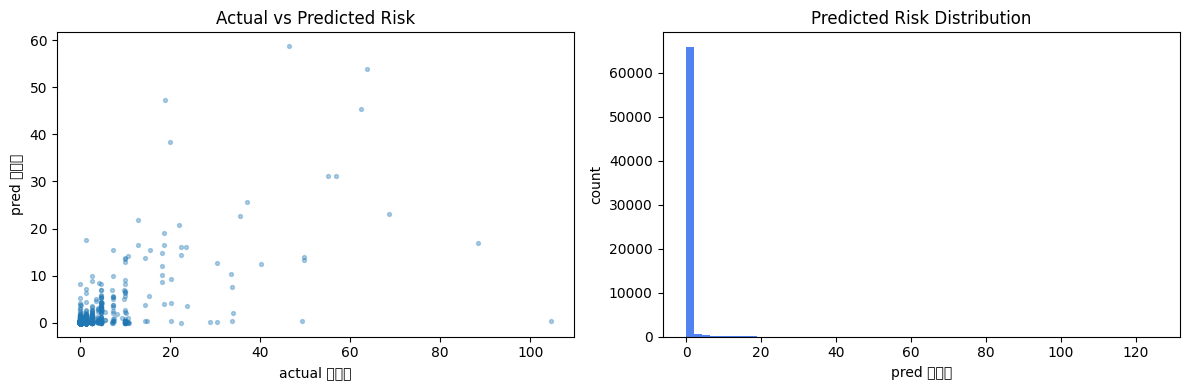

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sample = predictions.sample(min(len(predictions), 5000), random_state=42)
axes[0].scatter(sample['위험도'], sample['pred_위험도'], s=8, alpha=0.35)
axes[0].set_title('Actual vs Predicted Risk')
axes[0].set_xlabel('actual 위험도')
axes[0].set_ylabel('pred 위험도')

axes[1].hist(predictions['pred_위험도'], bins=60, color='#2563eb', alpha=0.8)
axes[1].set_title('Predicted Risk Distribution')
axes[1].set_xlabel('pred 위험도')
axes[1].set_ylabel('count')

plt.tight_layout()
plt.show()

,loss,mae,rmse,val_loss,val_mae,val_rmse,learning_rate
95,0.0541,0.1681,0.3525,0.0551,0.1631,0.3596,0.0000
96,0.0540,0.1680,0.3522,0.0551,0.1630,0.3597,0.0000
97,0.0543,0.1684,0.3534,0.0551,0.1628,0.3597,0.0000
98,0.0543,0.1683,0.3531,0.0550,0.1630,0.3594,0.0000
99,0.0541,0.1681,0.3525,0.0551,0.1630,0.3595,0.0000


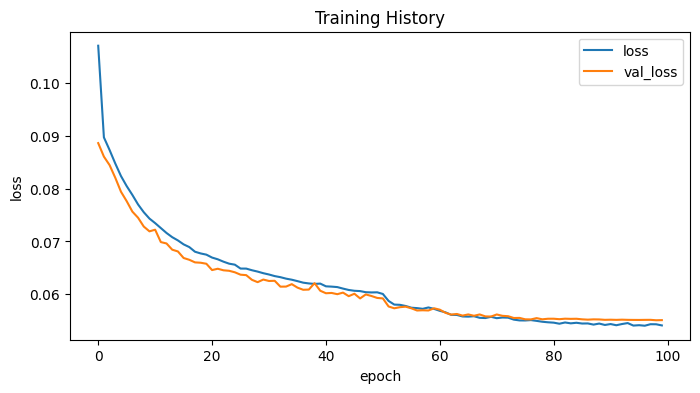

In [8]:
if history_path is not None:
    history = pd.read_csv(history_path)
    display(history.tail())
    loss_columns = [column for column in ['loss', 'val_loss'] if column in history.columns]
    if loss_columns:
        history[loss_columns].plot(figsize=(8, 4), title='Training History')
        plt.xlabel('epoch')
        plt.ylabel('loss')
        plt.show()
else:
    print('history CSV가 없어 학습 곡선을 표시하지 않습니다.')